In [1]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd())) 

In [2]:
import pandas as pd

from pathlib import Path

from models.transformer.model import TransformModel

project_root = Path().resolve().parents[1]


/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_path = project_root / "models" / "transformer.pt"
model = TransformModel.load(model_path)

In [4]:
dataset_path = project_root / "src" / "data" / "subm2_labels_revealed.csv"

df = pd.read_csv(dataset_path, sep=";")

In [5]:
X = df["Text"].tolist()
y = df["Label"].tolist()

predicted_labels = model.predict(X, y)

df["Labels"] = predicted_labels

/Users/diego/Workspace/Simb/mia/2-semestre/trabalhos/AP/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Accuracy: 46/100 (46.00%)


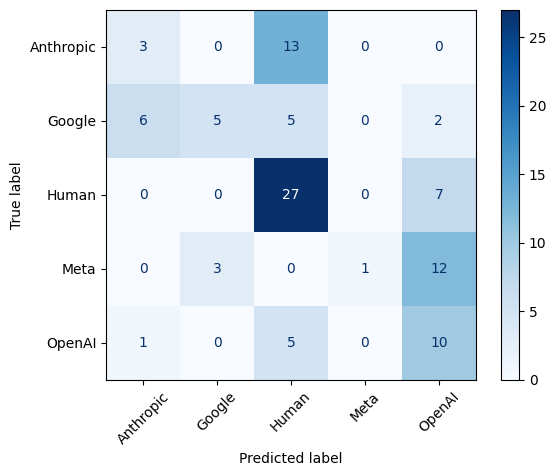

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.label_map.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

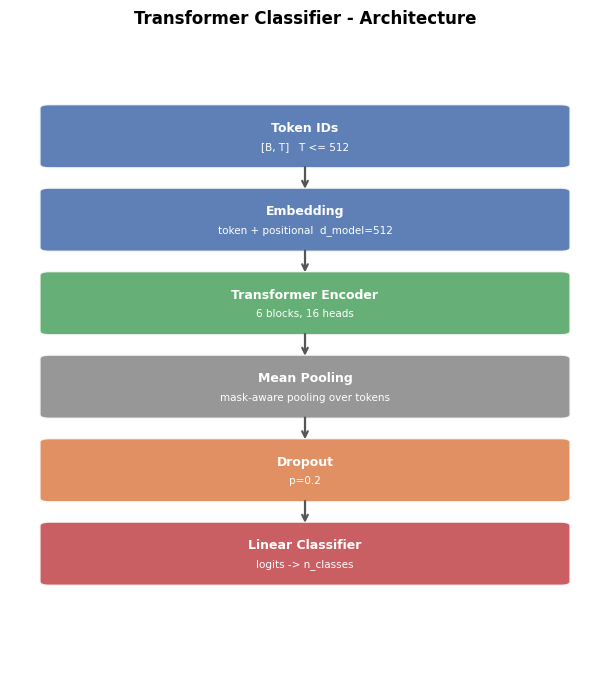

In [7]:
from models.transformer.train import TransformerTrainer

# Visual architecture diagram (model blocks)
TransformerTrainer.plot_architecture(seq_length=512)

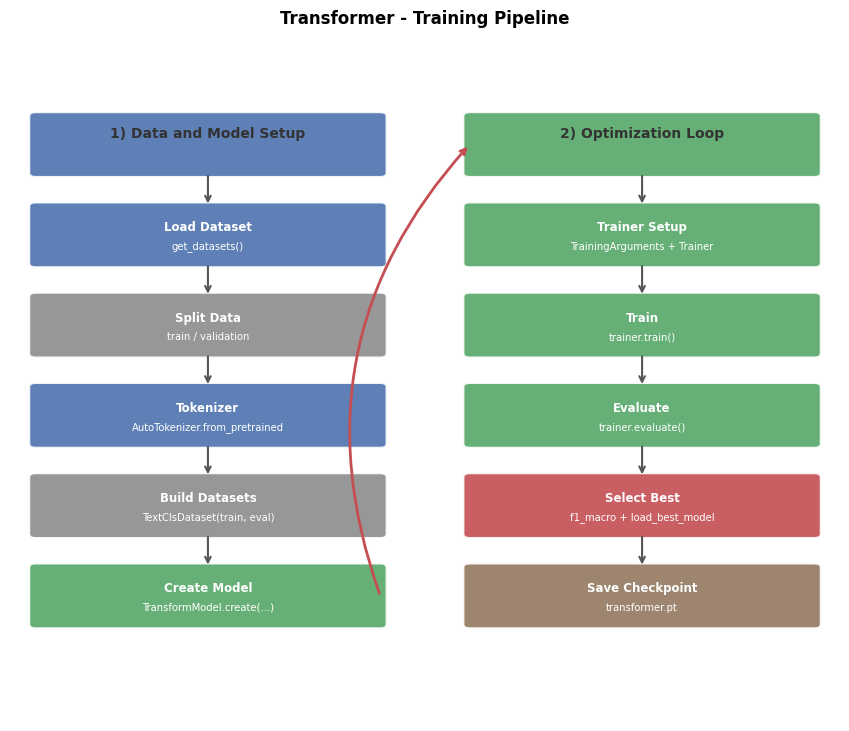

In [8]:
# Visual training workflow diagram (pipeline steps)
TransformerTrainer.plot_pipeline()

## Paper-Style Architecture View

This visualization follows the original Transformer paper more closely, but adapted to this project's model.

Key difference:
- the original paper shows an encoder-decoder architecture for sequence-to-sequence tasks
- this project uses only the encoder stack, followed by pooling and a classifier head for text classification

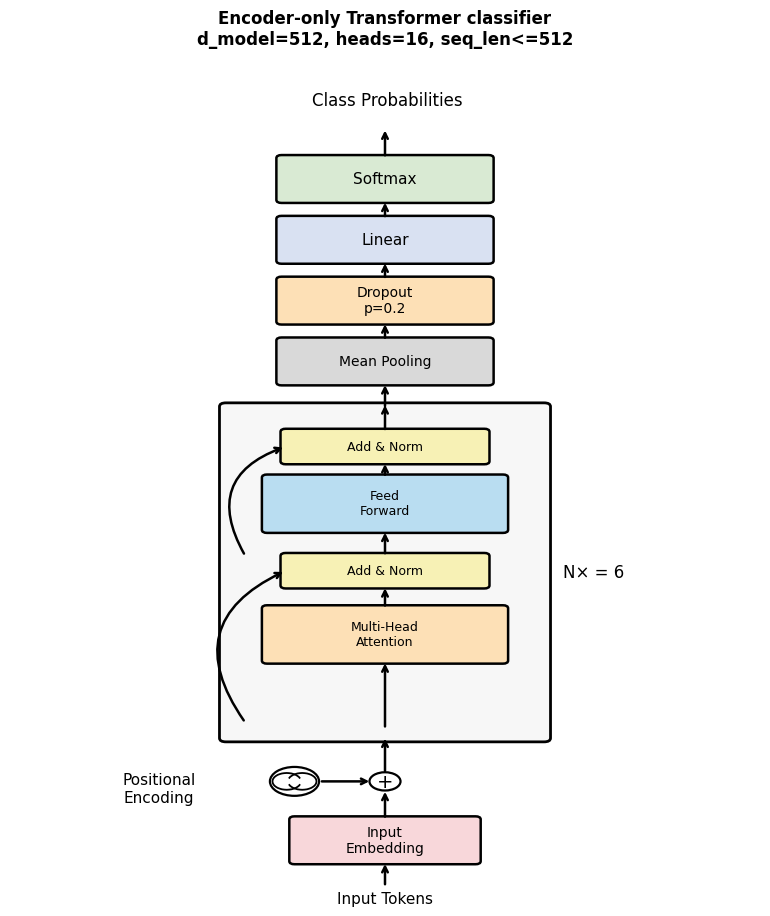

In [9]:
from models.transformer.train import TransformerTrainer

TransformerTrainer.plot_paper_style_architecture(seq_length=512)